In [60]:
import numpy as np
import pandas as pd
from scipy import ndimage
from hdbscan import HDBSCAN
from scipy.spatial import distance_matrix
from matplotlib import pyplot as plt
from sklearn import manifold, datasets
from sklearn.preprocessing import StandardScaler

In [61]:
df = pd.read_csv('Customer.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


Text(0, 0.5, 'Spending Score (1-100)')

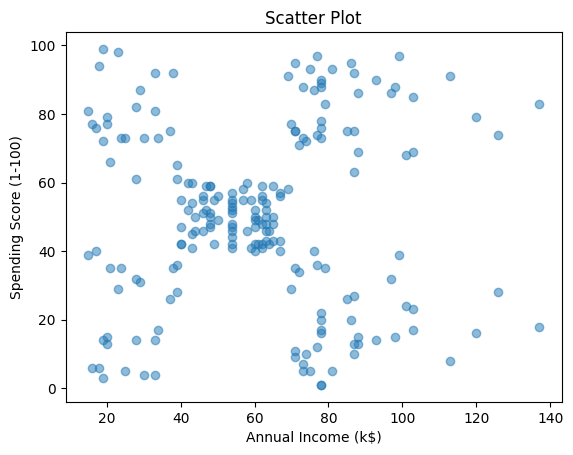

In [62]:
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], alpha=0.5)
plt.title('Scatter Plot')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')

In [63]:
clus_df = df[['Annual Income (k$)','Spending Score (1-100)']]
clus_df.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [64]:
norm_clus_df = StandardScaler().fit_transform(clus_df)
norm_clus_df

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992],
       [-1.66266033,  1.00159627],
       [-1.62449091, -1.71591298],
       [-1.62449091,  1.70038436],
       [-1.58632148, -1.83237767],
       [-1.58632148,  0.84631002],
       [-1.58632148, -1.4053405 ],
       [-1.58632148,  1.89449216],
       [-1.54815205, -1.36651894],
       [-1.54815205,  1.04041783],
       [-1.54815205, -1.44416206],
       [-1.54815205,  1.11806095],
       [-1.50998262, -0.59008772],
       [-1.50998262,  0.61338066],
       [-1.43364376, -0.82301709],
       [-1.43364376,  1.8556706 ],
       [-1.39547433, -0.59008772],
       [-1.39547433,  0.88513158],
       [-1.3573049 , -1.75473454],
       [-1.3573049 ,  0.88513158],
       [-1.24279661, -1.4053405 ],
       [-1.24279661,  1.23452563],
       [-1.24279661, -0.7065524 ],
       [-1.24279661,  0.41927286],
       [-1.20462718,

Text(0, 0.5, 'Spending Score (1-100)')

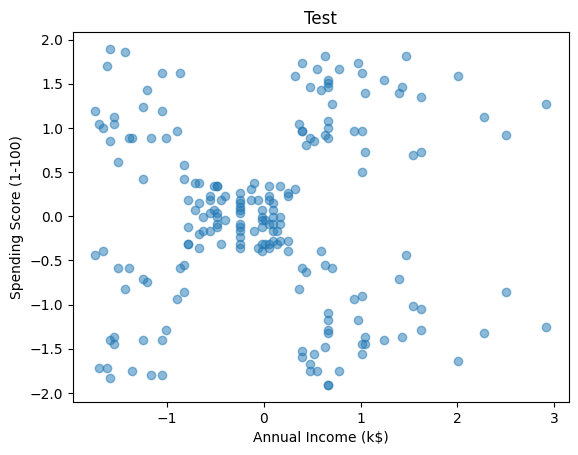

In [65]:
plt.scatter(norm_clus_df[:,0], norm_clus_df[:,1], alpha=0.5)
plt.title('Test')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')

In [66]:
hdbscan = HDBSCAN(min_cluster_size=5, min_samples=None, cluster_selection_epsilon=0).fit(norm_clus_df)
hdbscan.labels_

array([-1,  3,  1,  3, -1,  3,  1, -1,  1,  3,  1, -1,  1,  3,  1,  3,  4,
       -1, -1, -1,  4,  3,  1,  3,  1,  3, -1, -1,  4, -1,  1,  3, -1, -1,
        1,  3, -1,  3, -1, -1,  4, -1,  4,  4, -1,  4,  4,  4,  4,  4,  4,
        4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,
        4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,
        4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,
        4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,
        4,  4,  4,  4,  0, -1,  0,  4,  0,  2,  0,  2,  0,  4,  0,  2,  0,
        2,  0,  2,  0,  2,  0,  4,  0,  2,  0,  4,  0,  2,  0,  2,  0,  2,
        0,  2,  0,  2,  0,  2,  0, -1,  0,  2,  0, -1,  0,  2,  0, -1, -1,
        2,  0,  2,  0,  2,  0,  2,  0,  2,  0, -1,  0,  2,  0, -1,  0, -1,
       -1, -1,  0, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1])

In [71]:
n_clusters = len(set(hdbscan.labels_)) - (1 if -1 in hdbscan.labels_ else 0)
n_clusters

5

In [72]:
n_noise = len(hdbscan.labels_[hdbscan.labels_ == -1])
n_noise

37

In [73]:
noise_rate = (n_noise / len(hdbscan.labels_))*100
noise_rate

18.5

In [116]:
from sklearn.metrics import silhouette_score

epsilon = np.arange(0.0,0.6,0.1)
minValues = np.arange(2,10,1)

all_results = [] # Initialize an empty list to store results

for eps in epsilon:
  for minval in minValues:
    hdbscan_model = HDBSCAN(min_cluster_size=minval, min_samples=None, cluster_selection_epsilon=float(eps))
    hdbscan_model.fit(norm_clus_df)
    labels = hdbscan_model.labels_
    n_noise = int(np.sum(labels == -1))
    noise_pct = n_noise / len(labels) * 100

    # Calculate n_clusters and mask for the current iteration
    current_n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    mask = labels != -1 # Mask to exclude noise points

    if current_n_clusters > 1:
        # Ensure we only calculate silhouette_score for actual clusters (non-noise)
        sil = silhouette_score(norm_clus_df[mask], labels[mask])
    else:
        sil = np.nan

    all_results.append({
        'epsilon': eps,
        'min_cluster_size': minval,
        'noise_percentage': noise_pct,
        'silhouette_score': sil
    })

results_df = pd.DataFrame(all_results)
last_result = results_df.sort_values(by='noise_percentage', ascending=False)
last_result

,epsilon,min_cluster_size,noise_percentage,silhouette_score
5,0.0,7,25.0,0.626964
13,0.1,7,25.0,0.626964
29,0.3,7,25.0,0.626964
21,0.2,7,25.0,0.626964
37,0.4,7,25.0,0.626964
31,0.3,9,24.0,0.568014
15,0.1,9,24.0,0.568014
7,0.0,9,24.0,0.568014
47,0.5,9,24.0,0.568014
23,0.2,9,24.0,0.568014


In [117]:
hdbscan = HDBSCAN(min_cluster_size=int(last_result.iloc[0,1]), min_samples=None, cluster_selection_epsilon=float(last_result.iloc[0,0])).fit(norm_clus_df)
hdbscan.labels_

array([-1, -1, -1,  3, -1,  3,  1, -1,  1,  3,  1, -1,  1,  3,  1,  3, -1,
       -1, -1, -1, -1,  3,  1,  3,  1,  3, -1, -1,  4, -1, -1,  3, -1, -1,
       -1, -1, -1,  3, -1, -1,  4, -1,  4,  4, -1,  4,  4,  4,  4,  4,  4,
        4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,
        4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,
        4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,
        4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,
        4,  4,  4,  4,  0, -1,  0,  4,  0,  2,  0,  2,  0,  4,  0,  2,  0,
        2,  0,  2,  0,  2,  0, -1,  0,  2,  0, -1,  0,  2,  0,  2,  0,  2,
        0,  2,  0,  2,  0,  2,  0, -1,  0,  2,  0, -1,  0,  2,  0, -1, -1,
        2,  0,  2,  0,  2,  0,  2,  0,  2,  0, -1, -1,  2, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1])

In [118]:
n_clusters = len(set(hdbscan.labels_)) - (1 if -1 in hdbscan.labels_ else 0)
n_clusters

5

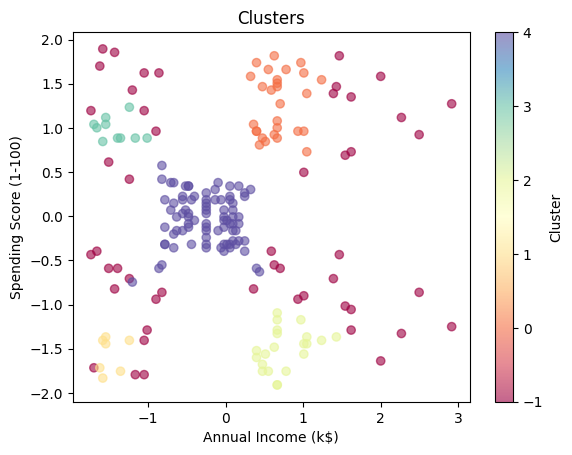

In [119]:
colors = plt.cm.Spectral(np.linspace(0, 1, len(hdbscan.labels_)))
plt.scatter(norm_clus_df[:, 0], norm_clus_df[:, 1],
            c=hdbscan.labels_, cmap='Spectral', alpha=0.6)
plt.colorbar(label='Cluster')
plt.title('Clusters')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()